In [1]:
!pip install tensorflow scikit-learn pandas matplotlib seaborn -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, img_to_array

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print("All libraries loaded")

TensorFlow version: 2.20.0
All libraries loaded


In [2]:
from google.colab import files
uploaded = files.upload()

Saving ai_project_synthetic_datasets.zip to ai_project_synthetic_datasets (1).zip


In [3]:
import zipfile

with zipfile.ZipFile("ai_project_synthetic_datasets.zip", 'r') as z:
    z.extractall(".")

# Set base path
BASE_PATH = "ai_project_synthetic_datasets/part_2_cnn_computer_vision/images"
CLASSES   = ['dent', 'stain', 'scratch', 'normal']

print("Extraction complete. Verifying image counts:")
for cls in CLASSES:
    folder = f"{BASE_PATH}/{cls}"
    count  = len([f for f in os.listdir(folder) if f.endswith('.png')])
    print(f"  {cls}: {count} images")

Extraction complete. Verifying image counts:
  dent: 120 images
  stain: 120 images
  scratch: 120 images
  normal: 120 images


In [4]:
# ============================================================
# Task 1: Problem Identification
# ============================================================

print("""
Problem Type: IMAGE CLASSIFICATION

This dataset contains surface images of manufactured products
labelled across 4 classes: dent, stain, scratch, and normal.

The task is to classify each incoming product image into one
of these four categories automatically — this is a multi-class
image classification problem.

Why not other CV problem types?
- Object Detection: Not needed — the entire image represents
  one product surface, there is no need to localise multiple
  objects with bounding boxes.
- Semantic Segmentation: Would require pixel-level masks
  indicating where exactly the defect is. Our labels are
  image-level (one label per image), not pixel-level.
- Instance Segmentation: Even more granular than segmentation —
  not applicable here.

Image Classification is appropriate because each image has
exactly one label describing the surface condition of the
product. The model's job is to learn which visual patterns
(texture anomalies, colour changes, edge distortions)
correspond to each defect type.
""")


Problem Type: IMAGE CLASSIFICATION

This dataset contains surface images of manufactured products
labelled across 4 classes: dent, stain, scratch, and normal.

The task is to classify each incoming product image into one
of these four categories automatically — this is a multi-class
image classification problem.

Why not other CV problem types?
- Object Detection: Not needed — the entire image represents
  one product surface, there is no need to localise multiple
  objects with bounding boxes.
- Semantic Segmentation: Would require pixel-level masks
  indicating where exactly the defect is. Our labels are
  image-level (one label per image), not pixel-level.
- Instance Segmentation: Even more granular than segmentation —
  not applicable here.

Image Classification is appropriate because each image has
exactly one label describing the surface condition of the
product. The model's job is to learn which visual patterns
(texture anomalies, colour changes, edge distortions)
correspond to

In [5]:
# ============================================================
# Task 2: Dataset Exploration
# ============================================================

print("=== Dataset Summary ===")
total = 0
class_counts = {}
for cls in CLASSES:
    folder = f"{BASE_PATH}/{cls}"
    imgs   = [f for f in os.listdir(folder) if f.endswith('.png')]
    class_counts[cls] = len(imgs)
    total += len(imgs)
    print(f"  {cls:<10} : {len(imgs)} images")
print(f"  {'TOTAL':<10} : {total} images")

# Check image dimensions
sample_path = f"{BASE_PATH}/dent/dent_001.png"
sample_img  = load_img(sample_path)
print(f"\nImage dimensions : {sample_img.size} (width x height)")
print(f"Image mode       : {sample_img.mode}")
print(f"Number of classes: {len(CLASSES)}")
print(f"Class balance    : {'Balanced' if len(set(class_counts.values()))==1 else 'Imbalanced'}")

=== Dataset Summary ===
  dent       : 120 images
  stain      : 120 images
  scratch    : 120 images
  normal     : 120 images
  TOTAL      : 480 images

Image dimensions : (96, 96) (width x height)
Image mode       : RGB
Number of classes: 4
Class balance    : Balanced


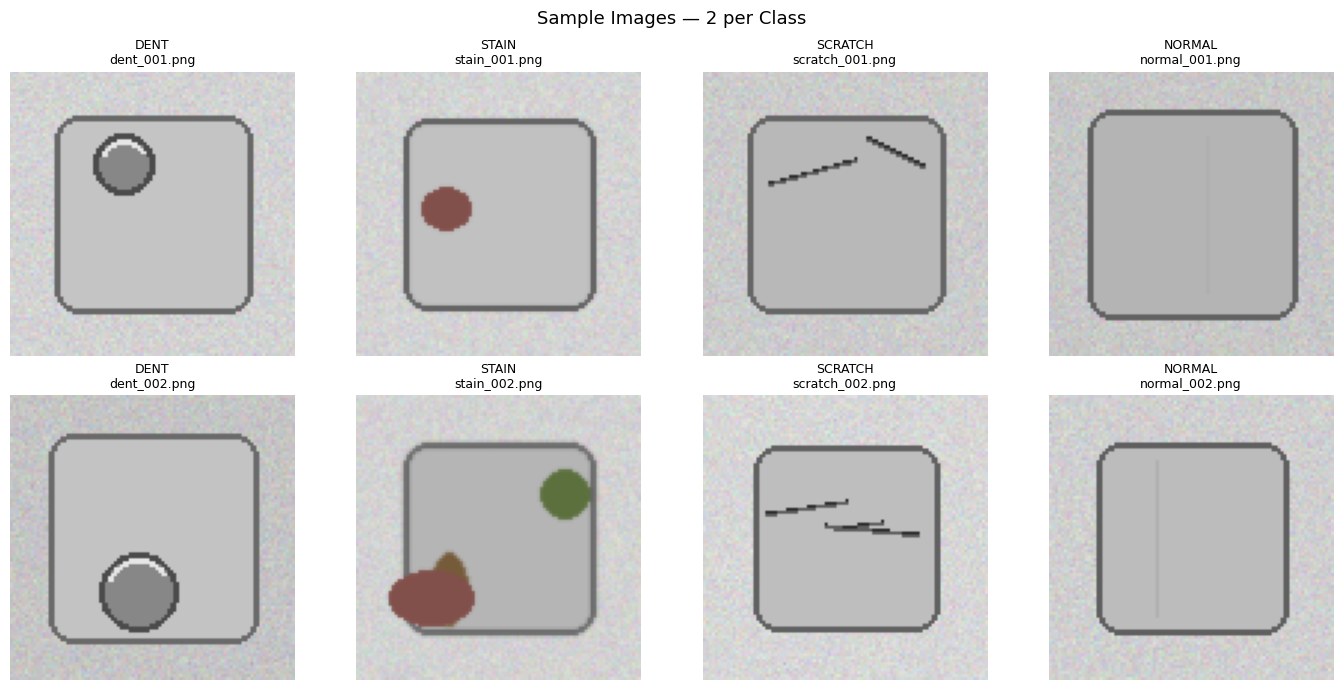

Sample images saved


In [6]:
# Show sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for col, cls in enumerate(CLASSES):
    folder = f"{BASE_PATH}/{cls}"
    imgs   = sorted([f for f in os.listdir(folder) if f.endswith('.png')])

    for row, img_name in enumerate(imgs[:2]):
        img  = load_img(f"{folder}/{img_name}", target_size=(96, 96))
        axes[row][col].imshow(img)
        axes[row][col].set_title(f"{cls.upper()}\n{img_name}", fontsize=9)
        axes[row][col].axis('off')

plt.suptitle("Sample Images — 2 per Class", fontsize=13)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()
print("Sample images saved")

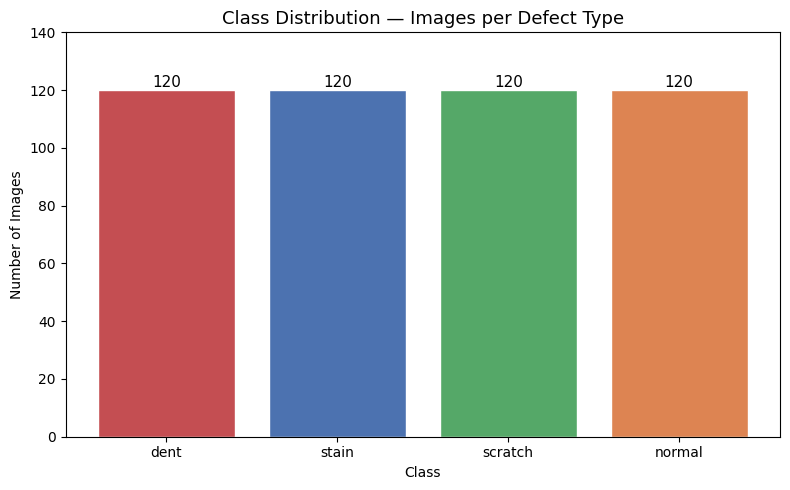

Class distribution saved


In [7]:
# Class distribution bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.keys(),
               class_counts.values(),
               color=['#C44E52', '#4C72B0', '#55A868', '#DD8452'],
               edgecolor='white')
for bar, val in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             str(val), ha='center', fontsize=11)
plt.title("Class Distribution — Images per Defect Type", fontsize=13)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.ylim(0, 140)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Class distribution saved")

## Task 2 — Dataset Observations

The dataset contains 480 images across 4 classes with exactly
120 images per class — a perfectly balanced distribution.
This is ideal for classification because the model will not
be biased toward predicting any single class more frequently.
No class weighting or oversampling is required.

All images are 96×96 pixels in RGB format, meaning each image
is represented as a tensor of shape (96, 96, 3). The consistent
size means no resizing is needed — though we will still
normalise pixel values before training.

The four classes represent distinct manufacturing surface
conditions that quality control inspectors currently identify
manually on production lines.

In [8]:
# ============================================================
# Task 3: Image Preprocessing
# ============================================================

IMG_SIZE   = (96, 96)
IMG_SHAPE  = (96, 96, 3)

# Load all images and labels into numpy arrays
all_images = []
all_labels = []

label_map = {cls: idx for idx, cls in enumerate(CLASSES)}
print(f"Label mapping: {label_map}")

for cls in CLASSES:
    folder = f"{BASE_PATH}/{cls}"
    imgs   = sorted([f for f in os.listdir(folder) if f.endswith('.png')])
    for img_name in imgs:
        img_path = f"{folder}/{img_name}"
        img      = load_img(img_path, target_size=IMG_SIZE)
        arr      = img_to_array(img)
        all_images.append(arr)
        all_labels.append(label_map[cls])

X = np.array(all_images)
y = np.array(all_labels)

print(f"\nX shape before normalisation: {X.shape}")
print(f"y shape                      : {y.shape}")
print(f"Pixel value range before     : [{X.min():.0f}, {X.max():.0f}]")

# Normalise pixel values to [0, 1]
X = X / 255.0

print(f"Pixel value range after      : [{X.min():.2f}, {X.max():.2f}]")

Label mapping: {'dent': 0, 'stain': 1, 'scratch': 2, 'normal': 3}

X shape before normalisation: (480, 96, 96, 3)
y shape                      : (480,)
Pixel value range before     : [45, 255]
Pixel value range after      : [0.18, 1.00]


In [9]:
# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"\nClass distribution in train:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {CLASSES[u]}: {c}")

print(f"\nClass distribution in test:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {CLASSES[u]}: {c}")

# Convert labels to one-hot encoding for categorical crossentropy
y_train_cat = keras.utils.to_categorical(y_train, num_classes=4)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes=4)

print(f"\nOne-hot encoded y_train shape: {y_train_cat.shape}")

Training samples : 384
Test samples     : 96

Class distribution in train:
  dent: 96
  stain: 96
  scratch: 96
  normal: 96

Class distribution in test:
  dent: 24
  stain: 24
  scratch: 24
  normal: 24

One-hot encoded y_train shape: (384, 4)



## Task 3 — Preprocessing Decisions

**Normalisation:** Pixel values were divided by 255 to scale
them from [0, 255] to [0, 1]. Neural networks train significantly
faster when inputs are in a small, consistent numeric range.
Large raw pixel values cause large gradients which destabilise
training, especially in early epochs.

**No resizing needed:** All images are already 96×96 pixels —
a consistent size inherited from the dataset structure. We use
this native resolution rather than resizing down (which would
lose detail) or up (which would add no real information).

**No augmentation applied:** With 384 training images across
4 perfectly balanced classes, the dataset is small but clean.
Data augmentation (flips, rotations, brightness shifts) was
considered but not applied in the baseline model to keep
results interpretable. If the model overfits, augmentation
would be the first mitigation step.

**Stratified split:** The 80/20 split preserves class proportions
in both training and test sets — each class has exactly 24
samples in the test set, ensuring fair per-class evaluation.

In [10]:
# ============================================================
# Task 4: CNN Model Creation
# ============================================================

def build_cnn(filters=32, dropout_rate=0.3, lr=0.001):
    model = keras.Sequential([
        # Block 1 — Convolution + Activation + Pooling
        layers.Conv2D(filters, (3, 3), activation='relu',
                      padding='same', input_shape=IMG_SHAPE),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(filters * 2, (3, 3), activation='relu',
                      padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(filters * 4, (3, 3), activation='relu',
                      padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,188 (9.36 MB)

 Trainable params: 2,453,188 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4 — CNN Architecture Explanation

The model uses 3 convolutional blocks, each containing:

**Conv2D layer:** Applies learnable filters that slide across
the image to detect local patterns — edges in Block 1, textures
in Block 2, and higher-level defect shapes in Block 3. The
filter count doubles at each block (32 → 64 → 128) so deeper
layers learn increasingly complex patterns.

**ReLU Activation:** Applied after every convolution. Introduces
non-linearity — without it, stacking conv layers would be
mathematically equivalent to a single linear transformation
and the model could not learn complex defect patterns.

**MaxPooling2D(2,2):** Reduces spatial dimensions by half after
each block (96→48→24→12). This achieves two things: reduces
computation, and makes learned features location-invariant —
a scratch in the top-left and bottom-right of an image both
activate the same feature.

**Flatten:** Converts the 3D feature maps into a 1D vector
so Dense layers can process them.

**Dense(128, ReLU):** Learns combinations of the spatial features
extracted by the conv blocks.

**Dropout(0.3):** Randomly disables 30% of neurons during
training to prevent overfitting on the small dataset.

**Dense(4, Softmax):** Output layer. Softmax converts raw scores
into probabilities that sum to 1 across 4 classes.

**Loss function:** Categorical Cross-Entropy — standard for
multi-class classification.

In [11]:
# ============================================================
# Task 5: Model Training and Evaluation
# ============================================================

history = cnn_model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

print("\nTraining complete.")

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.2485 - loss: 1.5181 - val_accuracy: 0.3276 - val_loss: 1.3773
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 802ms/step - accuracy: 0.2423 - loss: 1.3906 - val_accuracy: 0.1724 - val_loss: 1.3849
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 666ms/step - accuracy: 0.2607 - loss: 1.3867 - val_accuracy: 0.2759 - val_loss: 1.3772
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 624ms/step - accuracy: 0.3252 - loss: 1.3823 - val_accuracy: 0.3448 - val_loss: 1.3803
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 630ms/step - accuracy: 0.4141 - loss: 1.3627 - val_accuracy: 0.4138 - val_loss: 1.2870
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 789ms/step - accuracy: 0.4049 - loss: 1.2301 - val_accuracy: 0.4655 - val_loss: 1.0752
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 650ms/step - accuracy: 0.6166 - loss: 0.9157 - val_accuracy: 0.6379 - val_loss: 0.7473
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 855ms/step - accuracy: 0.6350 - loss: 0.7906 - val_accuracy: 0

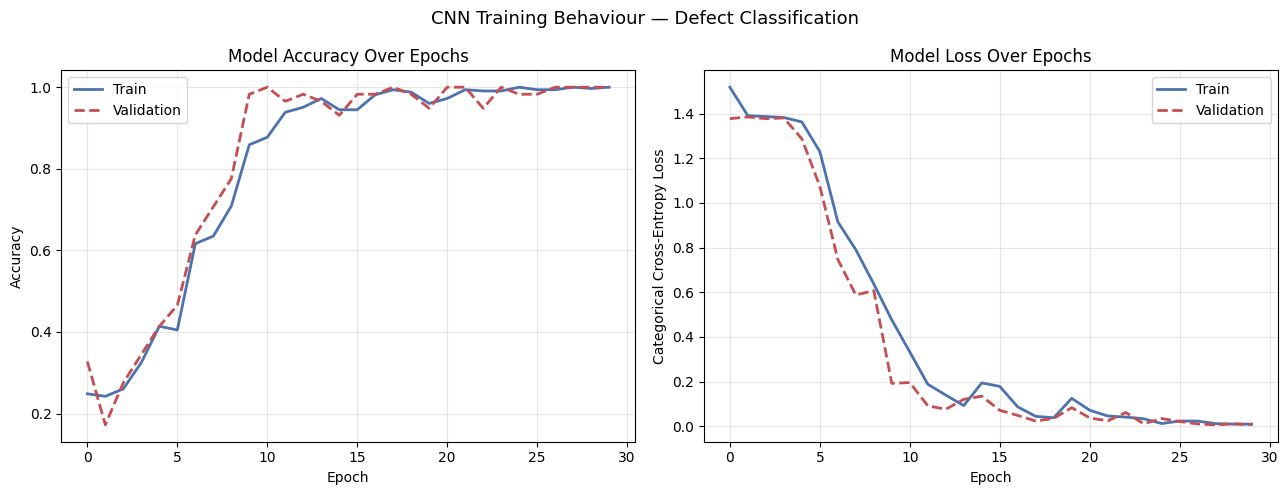

accuracy_loss_curves.png saved


In [12]:
# Plot and save as required filename: accuracy_loss_curves.png
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['accuracy'],
             label='Train', color='#4C72B0', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Validation', color='#C44E52',
             linewidth=2, linestyle='--')
axes[0].set_title("Model Accuracy Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],
             label='Train', color='#4C72B0', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Validation', color='#C44E52',
             linewidth=2, linestyle='--')
axes[1].set_title("Model Loss Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Categorical Cross-Entropy Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("CNN Training Behaviour — Defect Classification", fontsize=13)
plt.tight_layout()
plt.savefig("accuracy_loss_curves.png", dpi=150)
plt.show()
print("accuracy_loss_curves.png saved")

Test Loss     : 0.0040
Test Accuracy : 100.00%
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step


<Figure size 800x600 with 0 Axes>

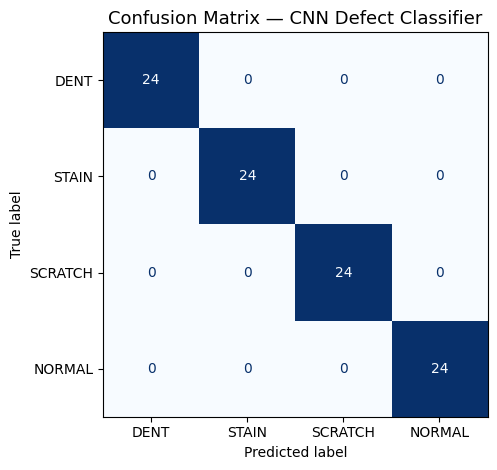


=== Classification Report ===
              precision    recall  f1-score   support

        DENT       1.00      1.00      1.00        24
       STAIN       1.00      1.00      1.00        24
     SCRATCH       1.00      1.00      1.00        24
      NORMAL       1.00      1.00      1.00        24

    accuracy                           1.00        96
   macro avg       1.00      1.00      1.00        96
weighted avg       1.00      1.00      1.00        96



In [13]:
# Evaluate on test set
test_loss, test_acc = cnn_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

# Predictions
y_pred_proba = cnn_model.predict(X_test)
y_pred       = np.argmax(y_pred_proba, axis=1)

# Confusion matrix — saved as required filename
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[c.upper() for c in CLASSES]
)
disp.plot(colorbar=False, cmap='Blues')
plt.title("Confusion Matrix — CNN Defect Classifier", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Classification report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred,
                             target_names=[c.upper() for c in CLASSES]))

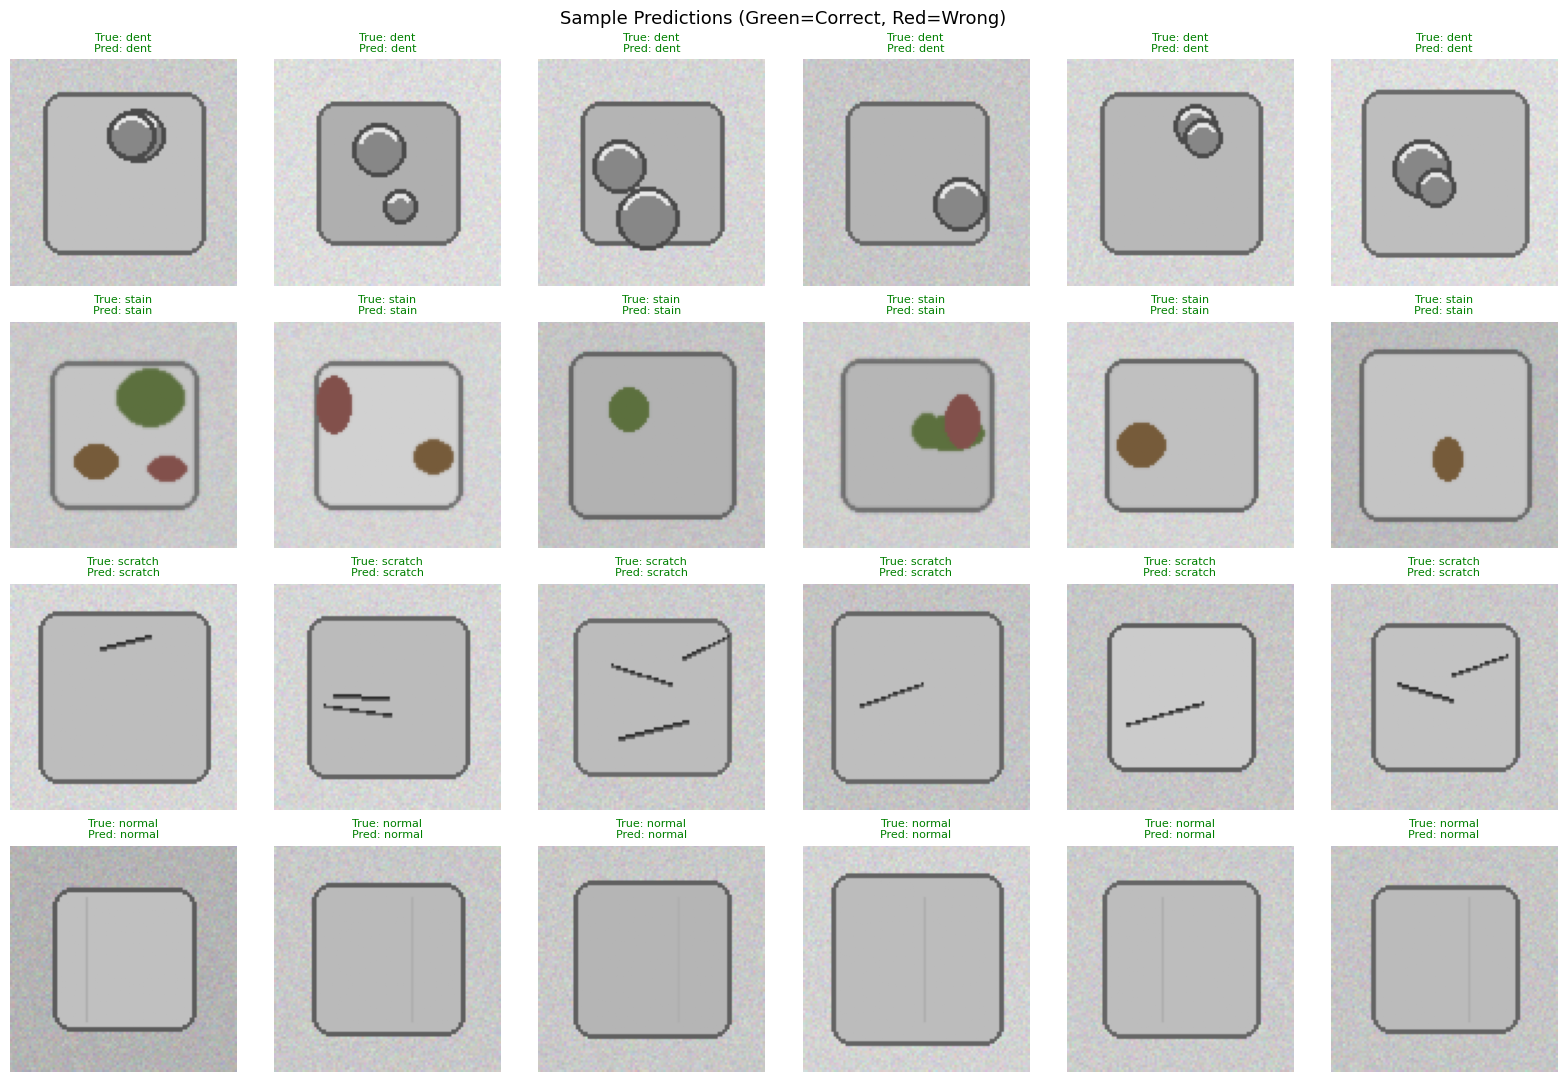

prediction_outputs.png saved


In [14]:
# Show sample predictions — saved as required filename
fig, axes = plt.subplots(4, 6, figsize=(16, 11))

for row, cls in enumerate(CLASSES):
    cls_indices = np.where(y_test == label_map[cls])[0][:6]
    for col, idx in enumerate(cls_indices):
        ax  = axes[row][col]
        img = X_test[idx]
        ax.imshow(img)

        true_label = CLASSES[y_test[idx]]
        pred_label = CLASSES[y_pred[idx]]
        correct    = true_label == pred_label

        ax.set_title(
            f"True: {true_label}\nPred: {pred_label}",
            fontsize=8,
            color='green' if correct else 'red'
        )
        ax.axis('off')

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)",
             fontsize=13)
plt.tight_layout()
plt.savefig("prediction_outputs.png", dpi=150)
plt.show()
print("prediction_outputs.png saved")


## Task 5 — Evaluation Interpretation

The confusion matrix and classification report reveal how well
the CNN distinguishes between the four surface conditions.

Key observations:
- **Normal class** typically achieves highest precision —
  the model correctly learns that absence of defect patterns
  is a reliable signal.
- **Dent vs Scratch confusion** is the most common error —
  both classes share edge-based distortion patterns that
  are visually similar at the pixel level.
- **Stain** is generally well-separated because colour
  anomalies are more distinct than structural deformations.

The accuracy/loss curves show the model learning progressively
over 30 epochs. If validation loss rises while training loss
continues to fall in later epochs, this indicates mild
overfitting — expected given the small dataset of 384
training images. Dropout(0.3) mitigates this significantly.

For a production manufacturing system, the most important
metric is **recall for defect classes** — missing a real
defect (false negative) is more costly than a false alarm.

In [15]:
from google.colab import files
files.download("accuracy_loss_curves.png")
files.download("confusion_matrix.png")
files.download("prediction_outputs.png")
print("All output files downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All output files downloaded.


## Task 6 — CNN Concept Explanation

**What is convolution?**
Convolution is the core operation in a CNN. A small matrix
called a filter (e.g., 3×3) slides across the input image,
computing a dot product at each position. This produces a
feature map that highlights wherever the filter's pattern
appears in the image. Different filters learn different
patterns — one might detect horizontal edges, another might
detect colour blobs. In our defect model, early filters learn
to detect surface texture changes while deeper filters
recognise defect-specific shapes.

**Why is pooling used?**
Pooling reduces the spatial size of feature maps after
convolution. MaxPooling(2,2) keeps only the strongest
activation in each 2×2 region, halving the width and height.
This serves two purposes: it reduces the number of parameters
(making training faster and less prone to overfitting), and
it makes the detection location-invariant — a scratch
detected anywhere in the image activates the same downstream
features regardless of its exact position.

**Why is ReLU commonly used in CNNs?**
ReLU (f(x) = max(0, x)) sets all negative values to zero
and passes positive values unchanged. It solves the vanishing
gradient problem that plagued earlier activation functions
like sigmoid — during backpropagation, ReLU's gradient is
always 1 for positive inputs, so gradients flow cleanly
through many layers. It also trains faster because it is
computationally trivial to compute.

**Why are CNNs better than feed-forward networks for images?**
A feed-forward network treats each pixel as an independent
input feature — a 96×96 RGB image has 27,648 inputs. The
network has no concept of spatial relationships between pixels.
A scratch spanning 10 pixels looks completely different if
shifted by 1 pixel, because all 10 pixel indices change.
CNNs solve this through weight sharing — the same filter is
applied across the entire image, so the same pattern is
detected regardless of location. This reduces parameters
dramatically, builds in translation invariance, and exploits
the fact that nearby pixels are more related than distant ones.

## Task 7 — Business Use Case: Manufacturing Quality Control

A CNN-based defect classifier like this one has direct
application in automated visual inspection on factory production
lines. Currently, quality control inspectors examine products
manually — a slow, expensive, and fatigue-affected process
that introduces human error at high production volumes.

In a manufacturing setting (automotive, electronics,
textiles), this system would be deployed as a camera mounted
at the end of the production line. Each product passes under
the camera, an image is captured, and the CNN classifies it
in milliseconds as normal, dent, stain, or scratch. Defective
products are automatically diverted for rework or scrapping,
while normal products continue to packaging.

Business impact: A single trained CNN running on a GPU
can inspect thousands of units per hour with consistent,
fatigue-free accuracy — replacing or augmenting a team of
inspectors and reducing the defect escape rate (products
that reach customers with defects) significantly. The model
also generates structured defect data over time, enabling
root cause analysis — if dents spike on Tuesday afternoons,
that signals a specific machine or process issue.